# JPEG Encoding Principle Tutorial: From 0 to Mastery


This notebook follows the ATDL-style OpenCV learning path: theory first, runnable local demos second, then debugging rules, practice tasks, and references.

本 notebook 用“从 0 到精通”的路线讲清楚 JPEG 编码原理。你会学到：

- JPEG 为什么适合压缩照片
- RGB/BGR 为什么要转换到 YCbCr
- 4:2:0 色度抽样为什么能大幅减少数据
- 8x8 分块和 DCT 如何把像素变成频率
- 量化表为什么是 JPEG 有损压缩的核心
- ZigZag 扫描、游程编码和熵编码如何进一步压缩
- `cv2.imwrite(..., IMWRITE_JPEG_QUALITY, q)` 背后大概发生了什么
- 如何用代码手写一个“教学版 JPEG 编码器”的关键步骤

Core mindset:

`JPEG encoding = color transform + chroma subsampling + 8x8 DCT + quantization + entropy coding.`


## How to Use This Notebook

Recommended learning order:

1. Read Part 1 to build the compression mental model.
2. Run Part 2 cell by cell and inspect every intermediate image/matrix.
3. Modify quality, block position, and chroma sampling settings.
4. Use Part 3 as a debugging checklist when JPEG artifacts appear in real projects.

Suggested environment:

- Python 3.10+
- `opencv-python`
- `numpy`
- `matplotlib`

This notebook uses local `.jpg` / `.jpeg` images in the same folder when available. No external downloads are required.


## Part 1: Theoretical Foundations


### 1.1 What Problem Does JPEG Solve?

Raw images are huge. A 1920x1080 color image has:

`1920 * 1080 * 3 = 6,220,800 bytes` if each channel uses 8 bits.

JPEG compresses natural photos by exploiting three facts:

- neighboring pixels are usually similar
- human vision is more sensitive to brightness than color detail
- human vision is less sensitive to high-frequency detail than low-frequency structure

The key tradeoff:

`JPEG gets small files by throwing away information that humans usually notice less.`


### 1.2 The JPEG Encoding Pipeline

A simplified baseline JPEG encoder does this:

1. Convert RGB/BGR to YCbCr.
2. Optionally subsample Cb and Cr, often 4:2:0.
3. Split each channel into 8x8 blocks.
4. Shift values by `-128` so pixels are centered around zero.
5. Apply DCT to each 8x8 block.
6. Divide by a quantization table and round.
7. ZigZag scan the 8x8 coefficients into a 1D sequence.
8. Encode DC differences and AC zero runs.
9. Huffman-code the symbols and write JPEG marker segments.

Mental model:

`pixels -> frequencies -> quantized frequencies -> compact symbols -> bytes`


### 1.3 YCbCr and Chroma Subsampling

JPEG usually separates brightness from color:

- `Y`: luma / brightness
- `Cb`: blue-difference chroma
- `Cr`: red-difference chroma

Why? Human vision cares more about brightness detail than color detail. That means JPEG can keep Y at full resolution and store Cb/Cr at lower resolution.

Common sampling modes:

- `4:4:4`: no chroma subsampling
- `4:2:2`: half horizontal chroma resolution
- `4:2:0`: half horizontal and half vertical chroma resolution

Practical rule:

`For photos, 4:2:0 often saves many bytes with little visible damage; for sharp colored text, it can look bad.`


### 1.4 DCT: Pixels Become Frequencies

JPEG processes 8x8 blocks. The DCT, Discrete Cosine Transform, converts each block from spatial pixel values to frequency coefficients.

Important coefficients:

- top-left coefficient = DC value, roughly the average brightness of the block
- coefficients near top-left = low frequencies, broad smooth changes
- coefficients near bottom-right = high frequencies, fine texture and edges

Natural photos often have most energy in low frequencies. JPEG takes advantage of that.

`DCT does not lose information by itself; quantization after DCT loses information.`


### 1.5 Quantization: The Heart of JPEG Loss

After DCT, JPEG divides each frequency coefficient by a quantization value and rounds:

`quantized = round(dct_coeff / quant_table_value)`

Large quantization values make many high-frequency coefficients become zero. More zeros means easier compression, but also more lost detail.

JPEG quality settings usually scale the quantization tables:

- high quality: smaller quantization values, fewer zeros, larger file
- low quality: larger quantization values, more zeros, smaller file

Master-level habit:

`When JPEG looks blocky or blurry, inspect quantization first.`


### 1.6 ZigZag, RLE, and Huffman Coding

After quantization, many coefficients near the bottom-right of the 8x8 block become zero.

JPEG uses ZigZag order to scan low frequencies first and high frequencies last. This tends to gather long runs of zeros near the end.

Then it encodes:

- DC coefficient as a difference from the previous block's DC
- AC coefficients as `(zero_run_length, value)` pairs
- common symbols with short Huffman codes

The practical idea:

`Quantization creates zeros; ZigZag and entropy coding turn those zeros into short bit patterns.`


## Part 2: Coding Demo - Build the Intuition Step by Step


### 2.1 Imports and Helpers


In [1]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
except ImportError as exc:
    raise ImportError("OpenCV is not installed. Please run: pip install opencv-python") from exc

print("OpenCV version:", cv2.__version__)
print("Working directory:", os.getcwd())


def show_many(images, cols=3, figsize=(15, 8)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for idx, (title, image, cmap) in enumerate(images, start=1):
        plt.subplot(rows, cols, idx)
        if image.ndim == 2:
            plt.imshow(image, cmap=cmap or "gray", vmin=0, vmax=255 if image.dtype == np.uint8 else None)
        else:
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def normalize_for_display(array):
    array = array.astype(np.float32)
    return cv2.normalize(array, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


def pad_to_multiple(image, multiple=8):
    h, w = image.shape[:2]
    new_h = int(np.ceil(h / multiple) * multiple)
    new_w = int(np.ceil(w / multiple) * multiple)
    if image.ndim == 2:
        padded = np.zeros((new_h, new_w), dtype=image.dtype)
        padded[:h, :w] = image
    else:
        padded = np.zeros((new_h, new_w, image.shape[2]), dtype=image.dtype)
        padded[:h, :w] = image
    return padded, (h, w)


OpenCV version: 4.13.0
Working directory: /home/ubuntu/Documents/ComputerVision


/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### 2.2 Load a Local Image

This cell looks for local `.jpg` or `.jpeg` files in the notebook folder. You can replace `image_path` with your own file.


Candidates:
 - AOISPARK6_18.jpg
 - AOISPARK8_20.jpg
 - BIKUJUKO4_19.jpeg
Using: AOISPARK6_18.jpg
Demo shape: (512, 512, 3)


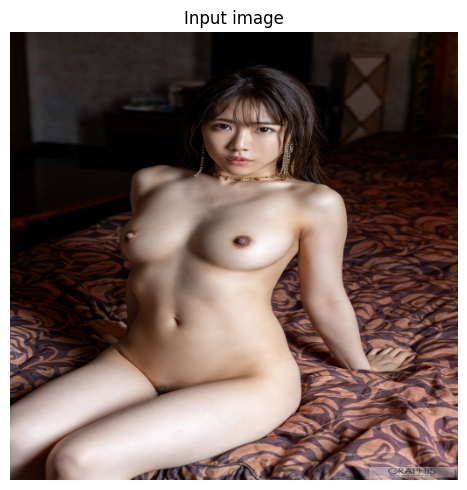

In [12]:
folder = Path.cwd()
candidates = sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")))
print("Candidates:")
for p in candidates:
    print(" -", p.name)

if not candidates:
    raise FileNotFoundError("Put a .jpg or .jpeg file in this folder, or set image_path manually.")

image_path = candidates[0]
image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise RuntimeError(f"OpenCV could not read {image_path}")

image_bgr = cv2.resize(image_bgr, (512, 512), interpolation=cv2.INTER_AREA)
print("Using:", image_path.name)
print("Demo shape:", image_bgr.shape)
show_many([("Input image", image_bgr, None)], cols=1, figsize=(5, 5))


### 2.3 RGB/BGR to YCbCr

OpenCV uses BGR channel order by default. JPEG-style encoding separates brightness from color, so we convert to YCrCb in OpenCV naming. Conceptually this is YCbCr; OpenCV stores channels as Y, Cr, Cb.


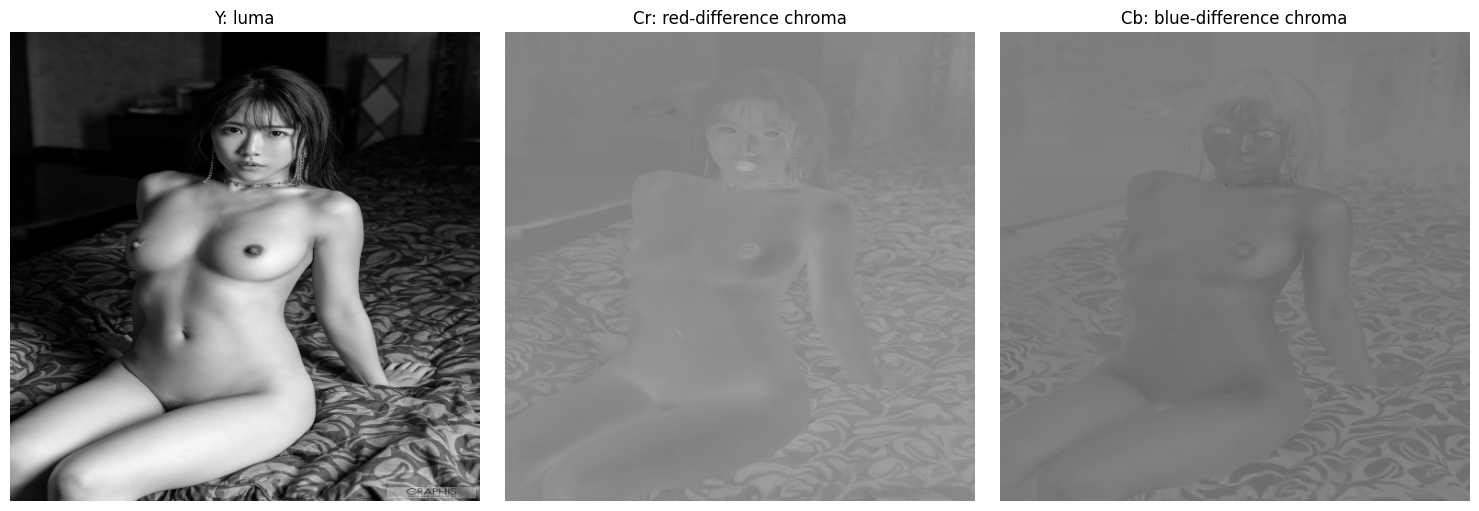

Y range: 0 - 250
Cr range: 117 - 175
Cb range: 91 - 142


In [9]:
ycrcb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2YCrCb)
Y, Cr, Cb = cv2.split(ycrcb)

show_many([
    ("Y: luma", Y, "gray"),
    ("Cr: red-difference chroma", Cr, "gray"),
    ("Cb: blue-difference chroma", Cb, "gray"),
], cols=3, figsize=(15, 5))

print("Y range:", int(Y.min()),"-", int(Y.max()))
print("Cr range:", int(Cr.min()),"-", int(Cr.max()))
print("Cb range:", int(Cb.min()),"-", int(Cb.max()))


### 2.4 Simulate 4:2:0 Chroma Subsampling

In 4:2:0, chroma channels are stored at half width and half height. To visualize the loss, we downsample Cb/Cr and then upsample them back.


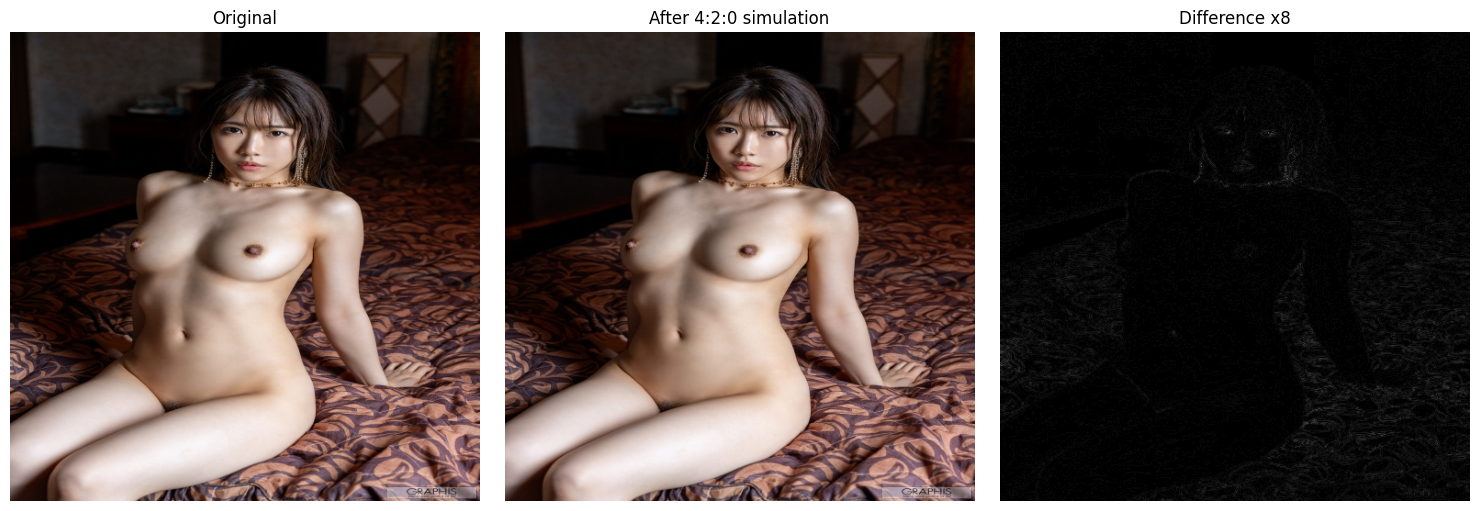

Chroma data ratio: 4:2:0 stores Cb/Cr at 1/4 resolution each
Mean pixel difference after chroma subsampling: 0.6103134155273438


In [16]:
h, w = Y.shape
Cr_small = cv2.resize(Cr, (w // 2, h // 2), interpolation=cv2.INTER_AREA)
Cb_small = cv2.resize(Cb, (w // 2, h // 2), interpolation=cv2.INTER_AREA)
Cr_up = cv2.resize(Cr_small, (w, h), interpolation=cv2.INTER_LINEAR)
Cb_up = cv2.resize(Cb_small, (w, h), interpolation=cv2.INTER_LINEAR)

subsampled_ycrcb = cv2.merge([Y, Cr_up, Cb_up])
subsampled_bgr = cv2.cvtColor(subsampled_ycrcb, cv2.COLOR_YCrCb2BGR)
diff_chroma = cv2.cvtColor(cv2.absdiff(image_bgr, subsampled_bgr), cv2.COLOR_BGR2GRAY)

show_many([
    ("Original", image_bgr, None),
    ("After 4:2:0 simulation", subsampled_bgr, None),
    ("Difference x8", np.clip(diff_chroma * 8, 0, 255).astype(np.uint8), "gray"),
], cols=3, figsize=(15, 5))

print("Chroma data ratio: 4:2:0 stores Cb/Cr at 1/4 resolution each")
print("Mean pixel difference after chroma subsampling:", float(diff_chroma.mean()))


### 2.5 One 8x8 Block Before and After DCT

JPEG centers pixel values around zero by subtracting 128, then applies DCT to each 8x8 block.


Original 8x8 Y block:
[[140. 140. 142. 138. 136. 132. 130. 126.]
 [146. 145. 143. 141. 138. 136. 133. 130.]
 [151. 149. 146. 143. 138. 138. 135. 132.]
 [152. 151. 148. 145. 141. 140. 138. 136.]
 [156. 154. 152. 150. 147. 145. 141. 140.]
 [156. 156. 154. 153. 150. 147. 145. 143.]
 [159. 157. 155. 154. 152. 148. 149. 145.]
 [159. 159. 157. 157. 151. 150. 149. 149.]]

DCT coefficients:
[[140.8  40.8  -2.4   0.9  -1.2   2.   -0.6  -0.8]
 [-49.5   3.7  -1.8   1.   -1.8  -0.2   1.3   0.9]
 [ -3.8  -3.4  -2.3  -1.7   0.    0.7  -0.7   1. ]
 [ -2.1  -1.7  -3.7   0.2   0.5  -0.7  -0.2   2.1]
 [ -2.   -0.5  -0.4  -1.6   0.   -0.4   1.   -0.2]
 [ -3.4  -0.1   0.4   0.1  -0.7   0.7  -0.8   1.6]
 [ -0.6   0.6  -0.4  -1.2  -0.6  -0.    0.5  -0.8]
 [  0.8   1.2   0.1   0.9   0.2   0.5   0.5   0.4]]

DC coefficient, roughly average brightness after centering: 140.75


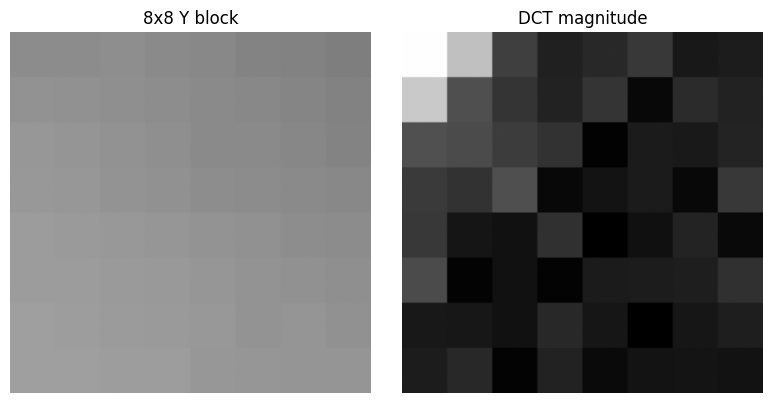

In [13]:
block_y, block_x = 160, 160
block = Y[block_y:block_y + 8, block_x:block_x + 8].astype(np.float32)
centered = block - 128.0
dct_block = cv2.dct(centered)

np.set_printoptions(precision=1, suppress=True)
print("Original 8x8 Y block:")
print(block)
print("\nDCT coefficients:")
print(dct_block)
print("\nDC coefficient, roughly average brightness after centering:", float(dct_block[0, 0]))

show_many([
    ("8x8 Y block", cv2.resize(block.astype(np.uint8), (160, 160), interpolation=cv2.INTER_NEAREST), "gray"),
    ("DCT magnitude", cv2.resize(normalize_for_display(np.log1p(np.abs(dct_block))), (160, 160), interpolation=cv2.INTER_NEAREST), "gray"),
], cols=2, figsize=(8, 4))


### 2.6 Quantization Tables and Quality Scaling

These are common JPEG standard luminance and chrominance quantization tables. Encoders scale them according to the quality setting.


In [17]:
QY_BASE = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68,109,103, 77],
    [24, 35, 55, 64, 81,104,113, 92],
    [49, 64, 78, 87,103,121,120,101],
    [72, 92, 95, 98,112,100,103, 99],
], dtype=np.float32)

QC_BASE = np.array([
    [17, 18, 24, 47, 99, 99, 99, 99],
    [18, 21, 26, 66, 99, 99, 99, 99],
    [24, 26, 56, 99, 99, 99, 99, 99],
    [47, 66, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
    [99, 99, 99, 99, 99, 99, 99, 99],
], dtype=np.float32)


def scaled_quant_table(base, quality):
    quality = int(np.clip(quality, 1, 100))
    scale = 5000 / quality if quality < 50 else 200 - 2 * quality
    table = np.floor((base * scale + 50) / 100)
    return np.clip(table, 1, 255).astype(np.float32)


for q in [30, 60, 90]:
    print(f"\nScaled luminance table, quality={q}:")
    print(scaled_quant_table(QY_BASE, q).astype(int))



Scaled luminance table, quality=30:
[[ 27  18  17  27  40  67  85 102]
 [ 20  20  23  32  43  97 100  92]
 [ 23  22  27  40  67  95 115  93]
 [ 23  28  37  48  85 145 133 103]
 [ 30  37  62  93 113 182 172 128]
 [ 40  58  92 107 135 173 188 153]
 [ 82 107 130 145 172 202 200 168]
 [120 153 158 163 187 167 172 165]]

Scaled luminance table, quality=60:
[[13  9  8 13 19 32 41 49]
 [10 10 11 15 21 46 48 44]
 [11 10 13 19 32 46 55 45]
 [11 14 18 23 41 70 64 50]
 [14 18 30 45 54 87 82 62]
 [19 28 44 51 65 83 90 74]
 [39 51 62 70 82 97 96 81]
 [58 74 76 78 90 80 82 79]]

Scaled luminance table, quality=90:
[[ 3  2  2  3  5  8 10 12]
 [ 2  2  3  4  5 12 12 11]
 [ 3  3  3  5  8 11 14 11]
 [ 3  3  4  6 10 17 16 12]
 [ 4  4  7 11 14 22 21 15]
 [ 5  7 11 13 16 21 23 18]
 [10 13 16 17 21 24 24 20]
 [14 18 19 20 22 20 21 20]]


### 2.7 Quantize One Block and Reconstruct It

This cell shows exactly where information is lost. DCT is reversible; rounding after division is not.


Quantized DCT block, quality=50:
[[ 9  4  0  0  0  0  0  0]
 [-4  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0]]

Zero coefficient count: 61 out of 64
Mean block reconstruction error: 1.15625


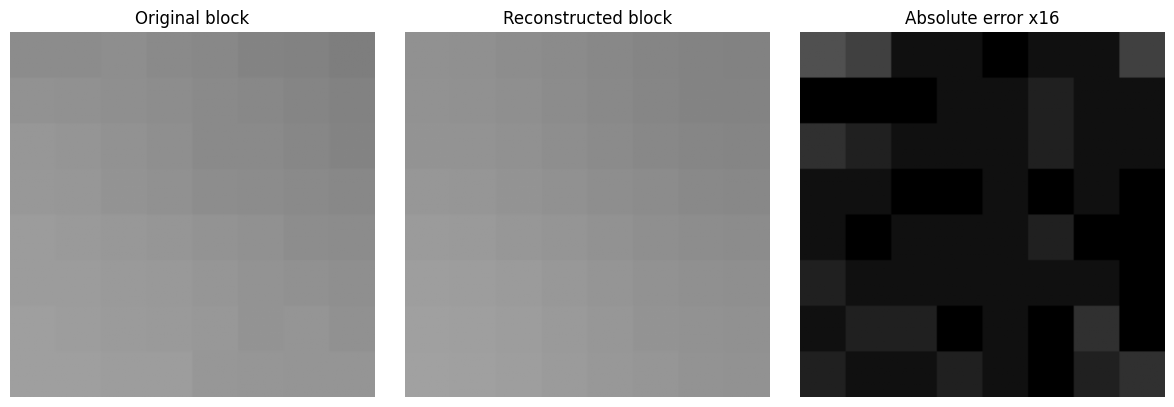

In [18]:
quality = 50
QY = scaled_quant_table(QY_BASE, quality)
quantized = np.round(dct_block / QY).astype(np.int32)
dequantized = quantized.astype(np.float32) * QY
reconstructed_block = np.clip(cv2.idct(dequantized) + 128, 0, 255).astype(np.uint8)
block_diff = cv2.absdiff(block.astype(np.uint8), reconstructed_block)

print("Quantized DCT block, quality=50:")
print(quantized)
print("\nZero coefficient count:", int((quantized == 0).sum()), "out of 64")
print("Mean block reconstruction error:", float(block_diff.mean()))

show_many([
    ("Original block", cv2.resize(block.astype(np.uint8), (160, 160), interpolation=cv2.INTER_NEAREST), "gray"),
    ("Reconstructed block", cv2.resize(reconstructed_block, (160, 160), interpolation=cv2.INTER_NEAREST), "gray"),
    ("Absolute error x16", cv2.resize(np.clip(block_diff * 16, 0, 255).astype(np.uint8), (160, 160), interpolation=cv2.INTER_NEAREST), "gray"),
], cols=3, figsize=(12, 4))


### 2.8 ZigZag Scan and Run-Length Encoding

ZigZag order visits low frequencies first, then high frequencies. Because high-frequency coefficients are often zero after quantization, the tail becomes easy to compress.


In [19]:
def zigzag_indices(n=8):
    indices = []
    for s in range(2 * n - 1):
        if s % 2 == 0:
            r = min(s, n - 1)
            c = s - r
            while r >= 0 and c < n:
                indices.append((r, c))
                r -= 1
                c += 1
        else:
            c = min(s, n - 1)
            r = s - c
            while c >= 0 and r < n:
                indices.append((r, c))
                r += 1
                c -= 1
    return indices


ZZ = zigzag_indices(8)


def zigzag_scan(block8):
    return np.array([block8[r, c] for r, c in ZZ])


def rle_ac(ac_values):
    pairs = []
    run = 0
    for value in ac_values:
        value = int(value)
        if value == 0:
            run += 1
        else:
            pairs.append((run, value))
            run = 0
    pairs.append((0, "EOB"))
    return pairs


zz_values = zigzag_scan(quantized)
rle_values = rle_ac(zz_values[1:])

print("ZigZag sequence:")
print(zz_values)
print("\nDC coefficient:", int(zz_values[0]))
print("AC run-length pairs:")
print(rle_values)


ZigZag sequence:
[ 9  4 -4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]

DC coefficient: 9
AC run-length pairs:
[(0, 4), (0, -4), (0, 'EOB')]


### 2.9 Reconstruct the Whole Luma Channel With a Teaching Encoder

This is not a complete JPEG file writer. It simulates the lossy block transform path for the Y channel: block -> DCT -> quantize -> dequantize -> inverse DCT.


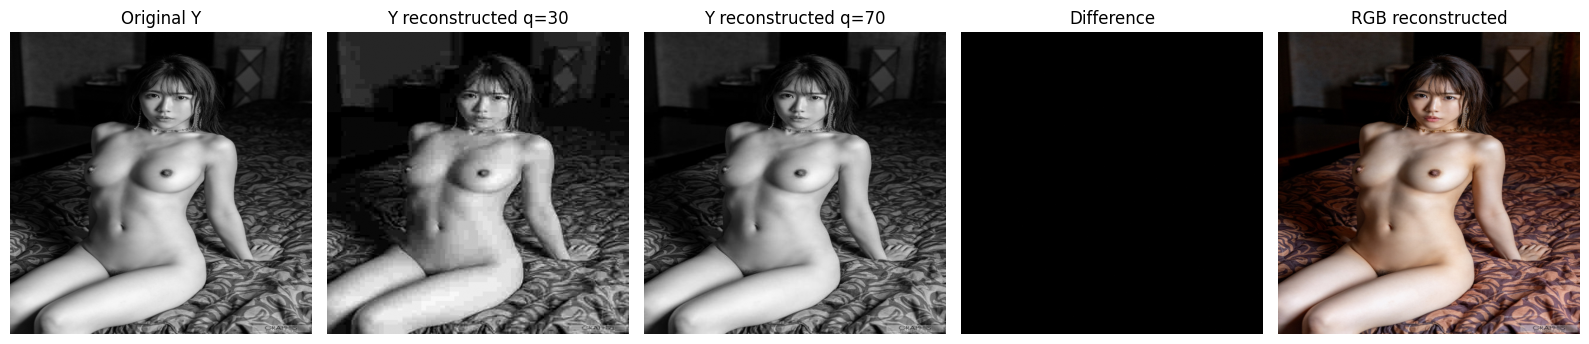

Zero ratio q=30: 0.956
Zero ratio q=70: 0.854
Zero ratio q=95: 0.287


In [38]:
def jpeg_like_channel_reconstruct(channel, quality=50, table_base=QY_BASE):
    padded, original_shape = pad_to_multiple(channel, 8)
    out = np.zeros_like(padded, dtype=np.float32)
    qtable = scaled_quant_table(table_base, quality)
    total_zero = 0
    total_coeff = 0

    for y in range(0, padded.shape[0], 8):
        for x in range(0, padded.shape[1], 8):
            b = padded[y:y + 8, x:x + 8].astype(np.float32) - 128
            coeff = cv2.dct(b)
            q = np.round(coeff / qtable)
            total_zero += int((q == 0).sum())
            total_coeff += q.size
            restored = cv2.idct(q * qtable) + 128
            out[y:y + 8, x:x + 8] = restored

    h, w = original_shape
    out = np.clip(out[:h, :w], 0, 255).astype(np.uint8)
    return out, total_zero / total_coeff


recon_y_30, zero_ratio_30 = jpeg_like_channel_reconstruct(Y, quality=10, table_base=QY_BASE)
recon_y_70, zero_ratio_70 = jpeg_like_channel_reconstruct(Y, quality=70, table_base=QY_BASE)
recon_y_95, zero_ratio_95 = jpeg_like_channel_reconstruct(Y, quality=100, table_base=QY_BASE)
diff_chroma_1 = cv2.absdiff(Y, recon_y_95)
RGB_recon = cv2.cvtColor(cv2.merge([recon_y_95, Cr, Cb]), cv2.COLOR_YCrCb2BGR)

show_many([
    ("Original Y", Y, "gray"),
    ("Y reconstructed q=30", recon_y_30, "gray"),
    ("Y reconstructed q=70", recon_y_70, "gray"),
    
    ("Difference", diff_chroma_1, "gray"),
    ("RGB reconstructed", RGB_recon, None)
    
], cols=5, figsize=(16, 4))

print("Zero ratio q=30:", round(zero_ratio_30, 3))
print("Zero ratio q=70:", round(zero_ratio_70, 3))
print("Zero ratio q=95:", round(zero_ratio_95, 3))


### 2.10 Compare OpenCV JPEG Quality Settings

OpenCV's real JPEG encoder also performs marker writing, entropy coding, chroma handling, and library-specific optimizations. This cell shows the practical size/error tradeoff.


[ WARN:0@17747.218] global grfmt_jpeg.cpp:733 write The value(120) for IMWRITE_JPEG_QUALITY must be between 0 to 100. It is fallbacked to 100
[ WARN:0@17747.225] global grfmt_jpeg.cpp:733 write The value(120) for IMWRITE_JPEG_QUALITY must be between 0 to 100. It is fallbacked to 100


quality | file_size_bytes | mean_abs_diff | max_abs_diff
     20 |           73234 |        4.6096 |           76
     40 |           99189 |        3.3909 |           60
     60 |          123848 |        2.8776 |           54
     80 |          179559 |        2.2332 |           30
    120 |          934419 |        0.6733 |           12


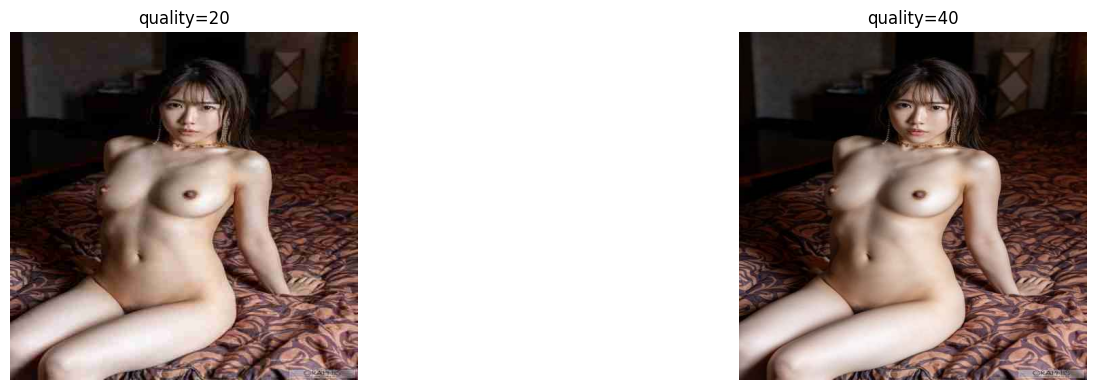

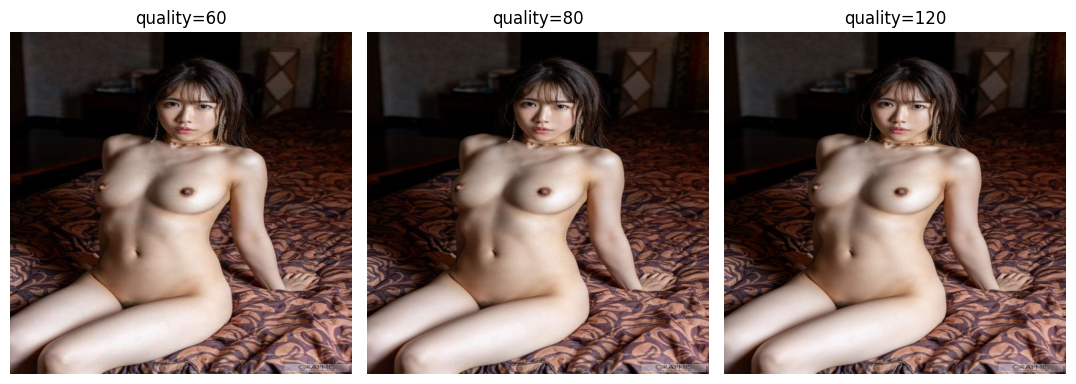

In [54]:
qualities = [20, 40, 60, 80, 120]
rows = []
preview_images = []

for q in qualities:
    out = image_path.with_name(f"{image_path.stem}_jpeg_quality_{q}.jpg")
    cv2.imwrite(str(out), image_bgr, [cv2.IMWRITE_JPEG_QUALITY, q])
    decoded = cv2.imread(str(out), cv2.IMREAD_COLOR)
    decoded_same_size = cv2.resize(decoded, (1281, 1920), interpolation=cv2.INTER_LINEAR)
    cv2.imwrite(str(out), decoded_same_size, [cv2.IMWRITE_JPEG_QUALITY, q])

    diff = cv2.cvtColor(cv2.absdiff(image_bgr, decoded), cv2.COLOR_BGR2GRAY)
    rows.append((q, out.stat().st_size, float(diff.mean()), int(diff.max())))
    preview_images.append((f"quality={q}", decoded, None))

print("quality | file_size_bytes | mean_abs_diff | max_abs_diff")
for row in rows:
    print(f"{row[0]:7d} | {row[1]:15d} | {row[2]:13.4f} | {row[3]:12d}")

show_many(preview_images[:2], cols=2, figsize=(18, 4))
show_many(preview_images[2:7], cols=5, figsize=(18, 4))


### 2.11 Inspect JPEG Markers Written by OpenCV

A real JPEG file wraps the compressed data in marker segments. This lightweight parser lists markers before the scan data.


In [57]:
MARKER_NAMES = {
    0xD8: "SOI Start Of Image",
    0xD9: "EOI End Of Image",
    0xDA: "SOS Start Of Scan",
    0xDB: "DQT Define Quantization Table",
    0xC0: "SOF0 Baseline Frame",
    0xC2: "SOF2 Progressive Frame",
    0xC4: "DHT Define Huffman Table",
    0xE0: "APP0 JFIF or application data",
    0xE1: "APP1 EXIF or XMP metadata",
    0xFE: "COM Comment",
}


def parse_jpeg_markers(path, max_markers=30):
    data = Path(path).read_bytes()
    if not data.startswith(b"\xFF\xD8"):
        raise ValueError("This file does not start with JPEG SOI bytes FF D8")

    markers = [(0, "FFD8", MARKER_NAMES[0xD8], None)]
    i = 2
    while i < len(data) - 1 and len(markers) < max_markers:
        if data[i] != 0xFF:
            i += 1
            continue
        while i < len(data) and data[i] == 0xFF:
            i += 1
        if i >= len(data):
            break
        code = data[i]
        marker = f"FF{code:02X}"
        name = MARKER_NAMES.get(code, "Other marker")
        i += 1

        if code in [0xD8, 0xD9] or 0xD0 <= code <= 0xD7:
            markers.append((i - 2, marker, name, None))
            if code == 0xD9:
                break
            continue

        if i + 2 > len(data):
            break
        segment_length = int.from_bytes(data[i:i + 2], "big")
        markers.append((i - 2, marker, name, segment_length))
        i += segment_length
        if code == 0xDA:
            markers.append((i, "...", "compressed scan data follows", None))
            break
    return markers


marker_file = image_path.with_name(f"{image_path.stem}_jpeg_quality_120.jpg")
for offset, marker, name, length in parse_jpeg_markers(marker_file):
    length_text = "" if length is None else f", length={length}"
    print(f"offset={offset:8d}  marker={marker}  {name}{length_text}")


offset=       0  marker=FFD8  SOI Start Of Image
offset=       2  marker=FFE0  APP0 JFIF or application data, length=16
offset=      20  marker=FFDB  DQT Define Quantization Table, length=67
offset=      89  marker=FFDB  DQT Define Quantization Table, length=67
offset=     158  marker=FFC0  SOF0 Baseline Frame, length=17
offset=     177  marker=FFC4  DHT Define Huffman Table, length=31
offset=     210  marker=FFC4  DHT Define Huffman Table, length=181
offset=     393  marker=FFC4  DHT Define Huffman Table, length=31
offset=     426  marker=FFC4  DHT Define Huffman Table, length=181
offset=     609  marker=FFDA  SOS Start Of Scan, length=12
offset=     623  marker=...  compressed scan data follows


## Part 3: Debugging and Mastery Roadmap

Debug JPEG quality problems in this order:

1. **Quality value**: low quality increases quantization and visible artifacts.
2. **Repeated encoding**: saving JPEG again and again accumulates loss.
3. **Chroma subsampling**: colored text, UI screenshots, and charts suffer more from 4:2:0.
4. **Block boundaries**: 8x8 block artifacts usually mean aggressive quantization.
5. **Ringing near edges**: high-frequency coefficients were quantized too strongly.
6. **Metadata expectations**: OpenCV save workflows may not preserve EXIF metadata.
7. **Content type**: photos compress well as JPEG; line art, text, masks, and diagrams often prefer PNG/WebP lossless.
8. **Resolution vs quality**: sometimes resizing slightly beats using a very low JPEG quality.

Master-level rule:

`Choose JPEG settings based on content: photos tolerate loss; text and graphics reveal it quickly.`


## Part 4: Practice Projects

Suggested progression:

1. **DCT block explorer**: click or manually choose different 8x8 blocks and compare their DCT coefficients.
2. **Quality curve**: plot JPEG quality vs file size vs mean absolute error.
3. **Quantization heatmap**: visualize which coefficients become zero as quality decreases.
4. **Chroma stress test**: create an image with red/blue text and compare 4:4:4 vs 4:2:0 behavior.
5. **Repeated save demo**: encode the same image 20 times and visualize accumulated artifacts.
6. **Tiny JPEG parser**: extend the marker parser to extract image width and height from SOF0.
7. **Teaching encoder**: reconstruct all Y, Cb, and Cr channels with DCT/quantization and compare to OpenCV's real output.


## Part 5: Quick API Reference

Core OpenCV and NumPy tools:

- `cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)`
- `cv2.split(image)` / `cv2.merge(channels)`
- `cv2.resize(image, size, interpolation=...)`
- `cv2.dct(block)`
- `cv2.idct(coefficients)`
- `cv2.imwrite(path, image, [cv2.IMWRITE_JPEG_QUALITY, quality])`
- `cv2.absdiff(a, b)`
- `np.round`, `np.clip`, `np.array`

JPEG vocabulary:

- `SOI`: start of image
- `DQT`: define quantization table
- `SOF0`: baseline frame header
- `DHT`: define Huffman table
- `SOS`: start of scan
- `EOI`: end of image
- `DC`: average-like block coefficient
- `AC`: remaining frequency coefficients

Useful references:

- JPEG standard text: https://www.w3.org/Graphics/JPEG/itu-t81.pdf
- OpenCV image codecs reference: https://docs.opencv.org/4.x/d4/da8/group__imgcodecs.html
- JPEG File Interchange Format overview: https://www.w3.org/Graphics/JPEG/jfif3.pdf


## Conclusion

JPEG encoding is not just “saving an image”. It is a carefully designed compression pipeline:

`BGR/RGB pixels -> YCbCr -> optional chroma subsampling -> 8x8 DCT -> quantization -> ZigZag/RLE/Huffman -> JPEG bytes`

The most important idea is quantization. DCT organizes visual information by frequency, then quantization removes less noticeable detail, especially high-frequency detail. Everything after that is mostly about representing the remaining numbers efficiently.
